In [19]:
import pandas as pd
df=pd.read_csv("/content/student_performance.csv")
df.shape

(30, 13)

In [20]:
print(df.isnull().sum())

student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [21]:
import sqlite3
conn = sqlite3.connect('student_performance.db')
df.to_sql('student_performance', conn, if_exists='replace', index=False)
print("DataFrame successfully stored in 'student_performance.db' as table 'student_performance'.")

DataFrame successfully stored in 'student_performance.db' as table 'student_performance'.


In [22]:
query_1 = "SELECT * FROM student_performance"
result_1 = pd.read_sql(query_1, conn)
print("Query 1: All Data")
display(result_1.head())

Query 1: All Data


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [23]:
query_2 = "SELECT department, AVG(programming_score) as avg_programming_score FROM student_performance GROUP BY department"
result_2 = pd.read_sql(query_2, conn)
print("Query 2: Average Programming Score per Department")
display(result_2)

Query 2: Average Programming Score per Department


,department,avg_programming_score
0,Civil,40.600000
1,Computer Science,89.230769
2,Electronics,61.500000
3,Mechanical,49.333333


In [24]:
query_3 = "SELECT gender, COUNT(student_id) as student_count FROM student_performance GROUP BY gender"
result_3 = pd.read_sql(query_3, conn)
print("Query 3: Student Count per Gender")
display(result_3)

Query 3: Student Count per Gender


,gender,student_count
0,Female,15
1,Male,15


In [25]:
query_4 = "SELECT name, math_score FROM student_performance ORDER BY math_score DESC LIMIT 5"
result_4 = pd.read_sql(query_4, conn)
print("Query 4: Top 5 Students by Math Score")
display(result_4)

Query 4: Top 5 Students by Math Score


,name,math_score
0,Ananya Das,95
1,Tanvi Mehta,93
2,Arjun Nair,92
3,Akanksha Yadav,91
4,Swati Kulkarni,90


In [26]:
query_5 = """SELECT admission_year,
                       AVG(math_score) as avg_math_score,
                       AVG(science_score) as avg_science_score,
                       AVG(english_score) as avg_english_score,
                       AVG(programming_score) as avg_programming_score
                FROM student_performance GROUP BY admission_year ORDER BY admission_year"""
result_5 = pd.read_sql(query_5, conn)
print("Query 5: Average Scores per Admission Year")
display(result_5)

Query 5: Average Scores per Admission Year


,admission_year,avg_math_score,avg_science_score,avg_english_score,avg_programming_score
0,2023,76.066667,77.833333,74.166667,67.6


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

/tmp/ipykernel_1218/2561453114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='department', y='avg_programming_score', data=result_2, palette='viridis')


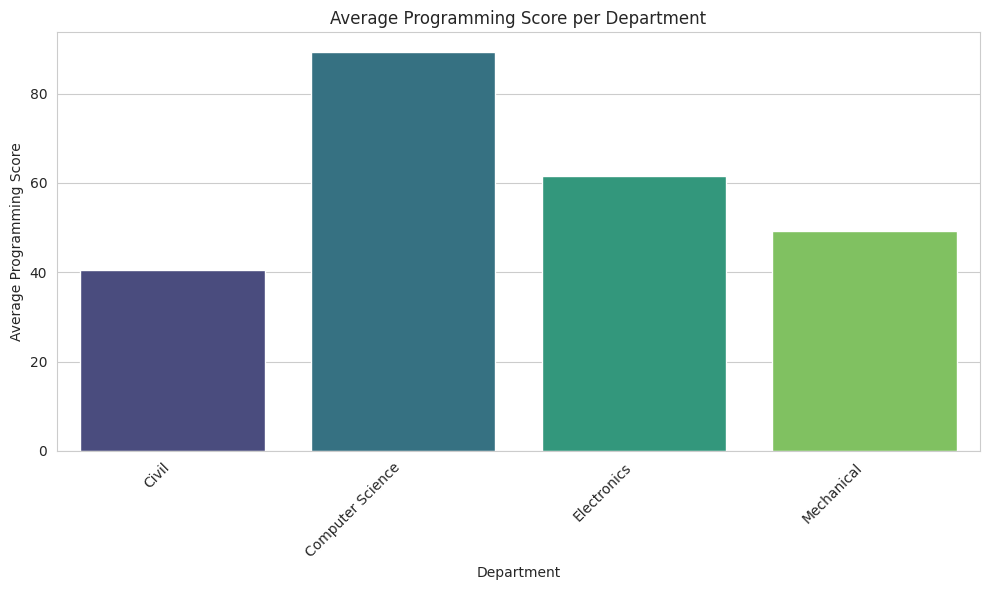

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='department', y='avg_programming_score', data=result_2, palette='viridis')
plt.title('Average Programming Score per Department')
plt.xlabel('Department')
plt.ylabel('Average Programming Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

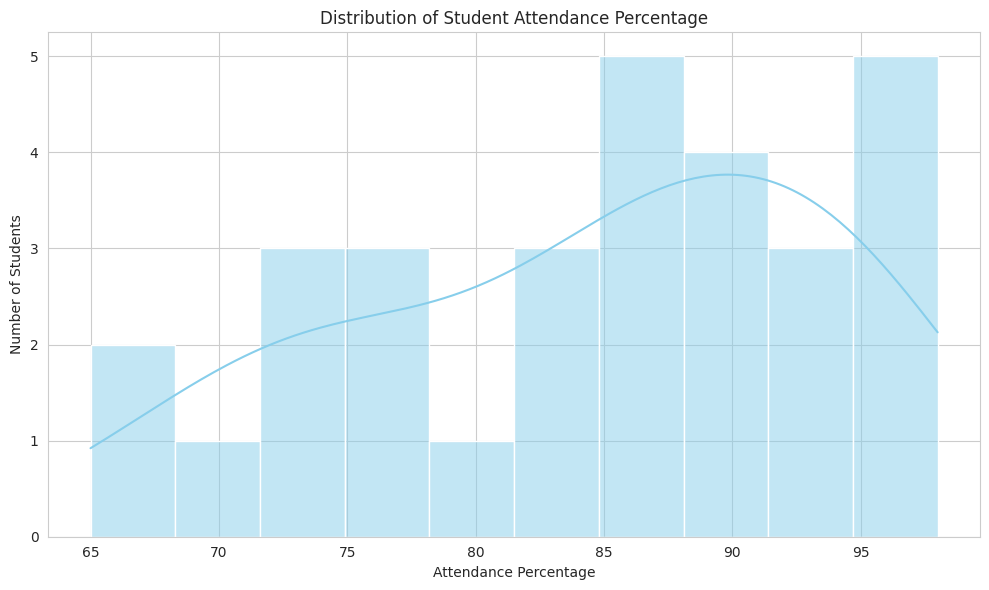

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['attendance_percentage'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Student Attendance Percentage')
plt.xlabel('Attendance Percentage')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

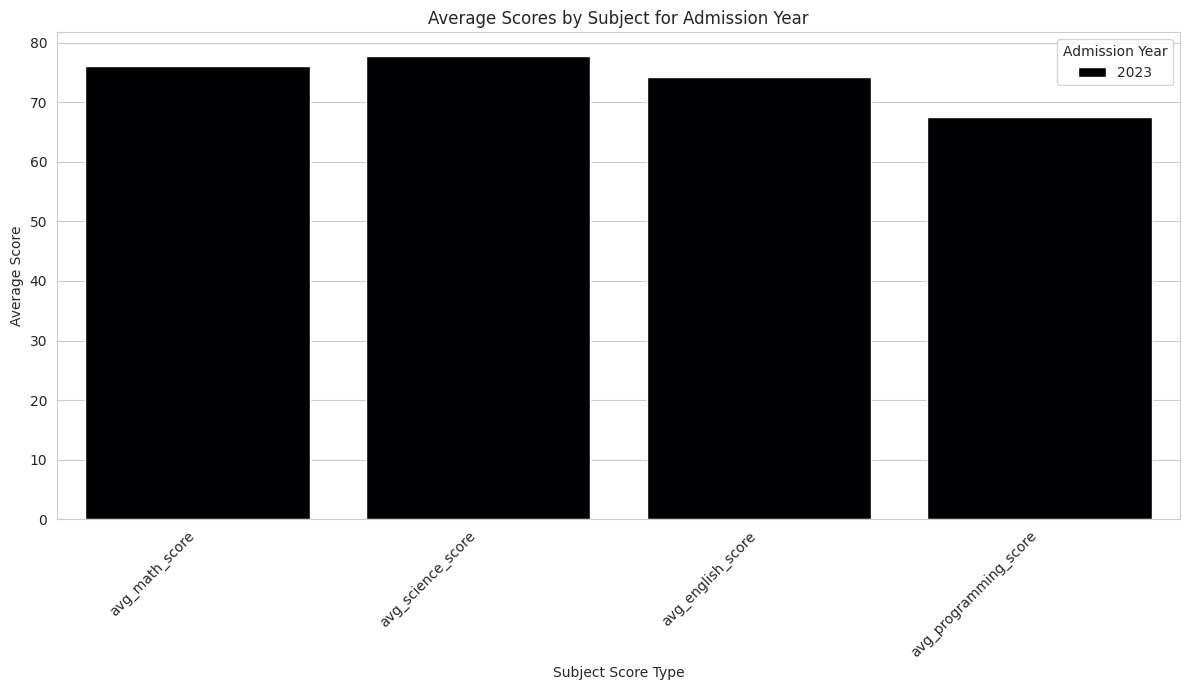

In [30]:
# Reshape result_5 for easier plotting of multiple score types
scores_melted = result_5.melt(id_vars=['admission_year'],
                              value_vars=['avg_math_score', 'avg_science_score', 'avg_english_score', 'avg_programming_score'],
                              var_name='score_type',
                              value_name='average_score')

plt.figure(figsize=(12, 7))
sns.barplot(x='score_type', y='average_score', hue='admission_year', data=scores_melted, palette='magma')
plt.title('Average Scores by Subject for Admission Year')
plt.xlabel('Subject Score Type')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Admission Year')
plt.tight_layout()
plt.show()

In [31]:
x=df[['math_score','science_score','attendance_percentage']]
y=df['programming_score']

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [33]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [34]:
y_pred=rf_model.predict(x_test)
